In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
import numpy as np
import random

In [3]:
client = bigquery.Client()

In [4]:
cset_colors = ["#0B1F41","#003DA6","#B53A6D","#7AC4A5","#F17F4C","#15AFD0","#839DC5","#E5BF21"]

In [20]:
query_text = """
SELECT
    cluster_id,
    x,
    y,
    NP_all_years
FROM eto_map_of_science.locations_with_metadata
ORDER BY cluster_id
"""

query = client.query(query_text)
cluster_locations = pd.DataFrame([{k:v for k,v in row.items()} for row in query]).set_index('cluster_id')

In [55]:
cluster_ids = list(cluster_locations.index)
random.seed(12)
random.shuffle(cluster_ids)
cluster_sample = cluster_locations.iloc[cluster_ids[:2000]]

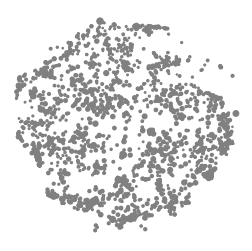

In [70]:
x = cluster_sample['x']
y = cluster_sample['y']
s = 20*cluster_sample['NP_all_years']/max(cluster_sample['NP_all_years'])
plt.figure(figsize=(3,3))
plt.scatter(x, y, s=s, c='grey')
plt.axis('equal')
plt.axis('off')
plt.show()

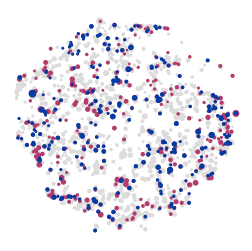

In [73]:
x = cluster_sample['x']
y = cluster_sample['y']
s = 20*cluster_sample['NP_all_years']/max(cluster_sample['NP_all_years'])
plt.figure(figsize=(3,3))
plt.scatter(x, y, s=s, c='gainsboro')
ncolored1=500
plt.scatter(x[:ncolored1],y[:ncolored1], s=s[:ncolored1], c=cset_colors[2])
ncolored2=250
plt.scatter(x[:ncolored2],y[:ncolored2], s=s[:ncolored2], c=cset_colors[1])
plt.axis('equal')
plt.axis('off')
plt.show()